<a href="https://colab.research.google.com/github/withfablue/PyTorch/blob/main/Chapter1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
import numpy as np
import torch

print(np.__version__)
print(torch.__version__)

2.0.2
2.11.0+cpu


In [ ]:
!pip install tqdm

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
import torch
import numpy as np

# Numpy 연산 확인
a = np.array([1, 2, 3])
print(a * 2)

# PyTorch 텐서 연산 확인
x = torch.tensor([1.0, 2.0, 3.0])
y = x * 2
print(y)

[2 4 6]
tensor([2., 4., 6.])


In [ ]:
import numpy as np

# 입력 벡터
x = np.array([1.0, 2.0, 3.0])   # shape: (3,)

# 가중치 벡터
w = np.array([0.5, 0.2, -0.3])  # shape: (3,)

# 편향
b = 0.1                         # shape: scalar

# 선형 결합
y = x @ w + b                   # shape: scalar
print('Numpy output:', y)

Numpy output: 0.10000000000000006


In [ ]:
import torch

# 입력 텐서
x = torch.tensor([1.0, 2.0, 3.0])  # shape: (3,)

# 가중치 텐서 (기울기 추적)
w = torch.tensor([0.5, 0.2, -0.3], requires_grad=True) # shape: (3,)

# 편향
b = torch.tensor(0.1, requires_grad=True)  #shape: ()

# 선형 결합
y = x @ w + b # shape: ()
print("PyTorch output:", y.item())

# 자동 미분
y.backward()
print('grad w:', w.grad)  # shape: (3,)
print('grad b:', b.grad)

PyTorch output: 0.09999994188547134
grad w: tensor([1., 2., 3.])
grad b: tensor(1.)


In [ ]:
import numpy as np
import torch

# NumPy 배열
A = np.array([[1., 2., 3.],
             [4., 5., 6.]])  # (2, 3)
b = np.array([1., 0., -1.])  # (3,)

# 브로드캐스팅 적용
C = A + b  # (2, 3)
print("NumPy broadcast result:\n", C)

# PyTorch 텐서
A_t = torch.tensor([[1., 2., 3.,],
                    [4., 5., 6.]])  # (2, 3)
b_t = torch.tensor([1., 0., -1.])   # (3,)

C_t = A_t + b_t  #(2, 3)
print("PyTorch broadcast result:\n", C_t)

NumPy broadcast result:
 [[2. 2. 2.]
 [5. 5. 5.]]
PyTorch broadcast result:
 tensor([[2., 2., 2.],
        [5., 5., 5.]])


In [ ]:
import torch

# 입력 텐서
x = torch.tensor([-1.0, 0.0, 1.0, 2.0])   # (4,)

# ReLU 적용
y = torch.relu(x)  # (4,)
print("ReLU output:", y)

ReLU output: tensor([0., 0., 1., 2.])


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

x = torch.tensor([1.0, 2.0, 3.0], device=device) # (3,)
w = torch.tensor([0.5, 0.2, -0.3], device=device, requires_grad=True) # (3,)
b = torch.tensor(0.1, device=device, requires_grad=True)

y = x @ w + b  # ()

print("result:", y.item())


using device: cuda
result: 0.09999994188547134


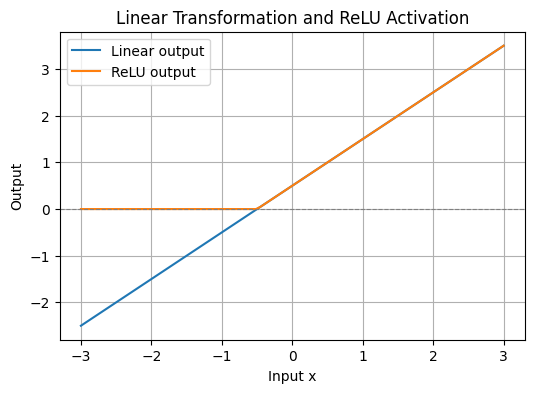

In [ ]:
import torch
import matplotlib.pyplot as plt

# 입력 값 생성
x = torch.linspace(-3, 3, steps=100)  # shape:(100,)

# 선형 변환 (가중치와 편향)
w = 1.0
b = 0.5
y_linear = w * x + b

# 비선형 함수 적용 (ReLU)
y_relu = torch.relu(y_linear)

# 시각화
plt.figure(figsize=(6,4))
plt.plot(x.numpy(), y_linear.numpy(), label="Linear output")
plt.plot(x.numpy(), y_relu.numpy(), label="ReLU output")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.xlabel("Input x")
plt.ylabel("Output")
plt.title("Linear Transformation and ReLU Activation")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 실습 문제 1, 로컬 환경 점검 스크립트 작성

import sys
import numpy as np
import torch

# 파이썬 버전
print(sys.version)

# 넘파이 버전
print(np.__version__)

# 파이토치 버전
print(torch.__version__)


print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
2.0.2
2.11.0+cu128
True
cuda


In [ ]:
# 실습 문제 2, 넘파이 선형 결합 함수 구현

import numpy as np
def linear_np(x, w, b):
  assert w.shape == x.shape, f"데이터와 가중치 형태가 맞지 않음, w: {w.shape}, x: {x.shape}"

  y = x @ w + b
  return y

x_1 = np.array([1.0, 2.0, 3.0])
w_1 = np.array([0.5, 0.3, 0.6])
b_1 = np.array(0.2)

x_2 = np.array([2.0, -0.2, 1.3])
w_2 = np.array([1.2, 3.4, -2.3])
b_2 = np.array(1.0)
print(linear_np(x_1, w_1, b_1))
print(linear_np(x_2, w_2, b_2))
# print(linear_np(np.array([1.0, 2.0]), np.array([3.0, 4.0, 5.0]), b_1))

3.1
-0.2699999999999998


In [ ]:
# 실습 문제 3, 파이토치 선형 결합과 자동 미분 구현

import torch
def linear_torch(x, w, b):
  assert w.shape == x.shape,  f"데이터와 가중치 형태가 맞지 않음, w: {w.shape}, x: {x.shape}"
  y = x @ w + b
  y.backward()
  return y.item(), w.grad, b.grad

x_1 = torch.tensor([1.0, 2.0, 3.0])
w_1 = torch.tensor([0.5, 0.3, 0.6], requires_grad=True)
b_1 = torch.tensor(0.2, requires_grad=True)

x_2 = torch.tensor([2.0, -0.2, 1.3])
w_2 = torch.tensor([1.2, 3.4, -2.3], requires_grad=True)
b_2 = torch.tensor(1.0, requires_grad=True)

print(linear_torch(x_1, w_1, b_1))
print(linear_torch(x_2, w_2, b_2))

(3.1000001430511475, tensor([1., 2., 3.]), tensor(1.))
(-0.26999974250793457, tensor([ 2.0000, -0.2000,  1.3000]), tensor(1.))


In [ ]:
# 실습 문제 4, ReLU 비선형 함수 동작 확인
import torch
x = torch.tensor([-2., -1., 0., 1., 2.])
print(torch.relu(x))

for a, b in zip(x, torch.relu(x)):
  print(a.item(), b.item())

#combined = torch.stack((x, torch.relu(x)), dim=1)
#print(combined)

tensor([0., 0., 0., 1., 2.])
-2.0 0.0
-1.0 0.0
0.0 0.0
1.0 1.0
2.0 2.0


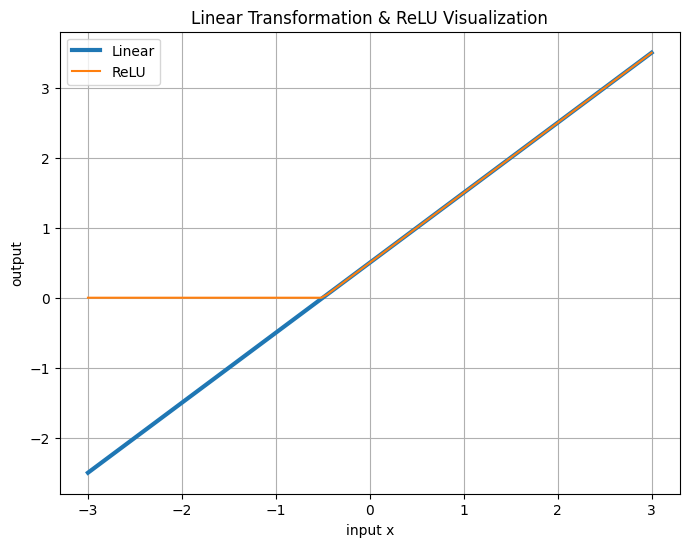

In [ ]:
# 실습 문제 5, 선형 변환과 ReLU 결과 시각화

import torch
import matplotlib.pyplot as plt

x = torch.linspace(-3, 3, steps=100)
w = 1.0
b = 0.5
y_linear = w*x + b
y_relu = torch.relu(y_linear)

plt.figure(figsize=(8,6))
plt.plot(x, y_linear, label='Linear', linewidth=3.0)
plt.plot(x, y_relu, label='ReLU', linewidth=1.5)

plt.xlabel("input x")
plt.ylabel("output")
plt.title("Linear Transformation & ReLU Visualization")
plt.legend()
#plt.axhline(0, color='gray', linestyle='--', linewidth=1.5)
plt.grid(True)
plt.show()


In [ ]:
# 실습 문제 6, 2층 신경망 연산의 shape 오류 구현과 수정
import torch
x = torch.rand(100, 10)
w1 = torch.rand(10, 20)
b1 = torch.rand(20,)
w2 = torch.rand(20, 10)
b2 = torch.rand(10,)

print(x.shape)
a1 = x @ w1 + b1
print(a1.shape)
z1 = torch.relu(a1)
print(z1.shape)
y = z1 @ w2 + b2
print(y.shape)

# If x.shape: (100,20) -> RuntimeError: mat1 and mat2 shapes cannot be multiplied (100x20 and 10x20)

torch.Size([100, 10])
torch.Size([100, 20])
torch.Size([100, 20])
torch.Size([100, 10])
